# OUTLIERS

In [41]:
import numpy as np
import seaborn as sns

In [42]:
arr=np.array([1,2,4,5,2,5,7,3,6,3,3,54,66,98,3,6,3,5,4,56])
arr

array([ 1,  2,  4,  5,  2,  5,  7,  3,  6,  3,  3, 54, 66, 98,  3,  6,  3,
        5,  4, 56])

In [43]:
q1=np.percentile(arr,25)
q3=np.percentile(arr,75)
iqr=q3-q1
lb=q1-(1.5*iqr)
ub=q3+(1.5*iqr)

print(q1,q3,iqr,lb,ub)

3.0 6.25 3.25 -1.875 11.125


In [44]:
li=[]
for i in arr:
    if i >= lb and i<=ub:
        li.append(i)
arr2=np.array(li)
arr2

array([1, 2, 4, 5, 2, 5, 7, 3, 6, 3, 3, 3, 6, 3, 5, 4])

<Axes: >

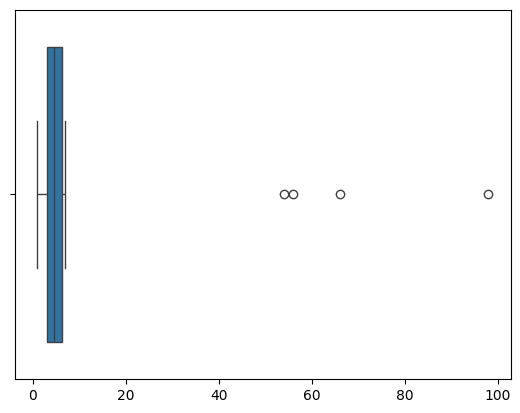

In [45]:
sns.boxplot(x=arr)

<Axes: >

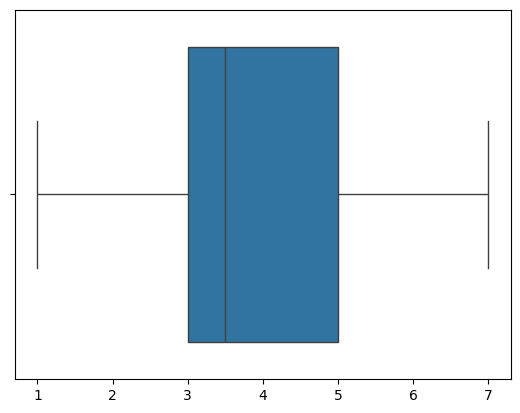

In [46]:
sns.boxplot(x=arr2)

# 5 number summary
* min
* q1(25th percentile)
* q2(50th percentile)
* q3(75th percentile)
* max


# Z-test

In [47]:
#z-test
import numpy as np 
from scipy.stats import norm

In [48]:
sample=[172,174,168,169,171,173,175,170,169,172]
pop_mean=170
pop_std=3
samp_mean=np.mean(sample)
n=len(sample)

In [49]:
z_score=(samp_mean-pop_mean)/(pop_std/np.sqrt(n))
z_score

np.float64(1.3703203194063098)

In [50]:
alpha=0.05
p_value=2*(1-norm.cdf(abs(z_score)))
p_value

np.float64(0.17058693287143756)

In [51]:
if p_value>alpha:
    print("accept null hypothesis")
else:
    print("reject null hypothesis")

accept null hypothesis


# t-test

In [52]:
import numpy as np
from scipy import stats

In [53]:
sample=[172,174,168,169,171,173,175,170,169,172]

In [54]:
sample_mean=np.mean(sample)
sample_std=np.std(sample,ddof=1)
n=len(sample)
mean_pop=170     #dynamic

In [55]:
t_stat=(sample_mean - mean_pop)/(sample_std/np.sqrt(n))
t_stat

np.float64(1.7782469350914734)

In [56]:
p_val=2*(1-stats.t.cdf(abs(t_stat),df=n-1))
alpha=0.05

In [58]:
if p_val>alpha:
    print("accept null hypothesis")
else:
    print("reject null hypothesis")

accept null hypothesis


# two sample test

In [59]:
import numpy as np 
from scipy import stats

In [60]:
a=[85,88,90,92,87,85,89,91,86,88]
b=[82,84,80,83,81,79,78,85,84,83]
t_stats,p_value=stats.ttest_ind(a,b,equal_var=False)


In [62]:
alpha=0.05
if p_value>alpha:
    print("accept null hypothesis")
else:
    print("reject null hypothesis")

reject null hypothesis


# chi-square

In [63]:
import numpy as np 
import seaborn as sns 
from scipy.stats import chi2_contingency
import pandas as pd 

In [64]:
df= sns.load_dataset('titanic')

In [65]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [66]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [67]:
contingency_table=pd.crosstab(df['sex'],df['survived'])
contingency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [68]:
chi2,p_value,dof,expected=chi2_contingency(contingency_table)

In [69]:
expected

array([[193.47474747, 120.52525253],
       [355.52525253, 221.47474747]])

In [70]:
p_value

np.float64(1.1973570627755645e-58)

In [71]:
chi2

np.float64(260.71702016732104)

In [72]:
alpha=0.05

In [73]:
if p_value>alpha:
    print("accept null hypothesis")
else:
    print("reject null hypothesis")

reject null hypothesis


# anova test

In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy.stats import f_oneway

In [4]:
df=sns.load_dataset('titanic')

In [5]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [9]:
df=df[['pclass','age']].dropna()

In [10]:
df['pclass'].unique()

array([3, 1, 2])

In [11]:
class_1=df[df['pclass']==1]['age']
class_2=df[df['pclass']==2]['age']
class_3=df[df['pclass']==3]['age']

In [12]:
f_stats,p_value=f_oneway(class_1,class_2,class_3)

In [13]:
f_stats

np.float64(57.44348434067624)

In [14]:
alpha=0.05
if p_value>alpha:
    print("accept null hypothesis")
else:
    print("reject null hypothesis")

reject null hypothesis
